In [ ]:
"""
Transfer learning is a technique where a model trained on one task is reused for a related task, especially when the new task has limited data. 
This helps in the following ways:

Uses learned features from the first task
Reduces training time for the new task
Improves accuracy with less data
Uses general features that work across tasks
traditional_machine_learning_.webp
"""

In [3]:
import os
import gzip
import numpy as np
import tensorflow as tf
from tensorflow.keras.utils import to_categorical

def load_mnist_from_local(data_dir):

    files = {
        'train_images': 'train-images-idx3-ubyte',
        'train_labels': 'train-labels-idx1-ubyte',
        'test_images':  't10k-images-idx3-ubyte',
        'test_labels':  't10k-labels-idx1-ubyte',
    }

    def find_file(name):
        path = os.path.join(data_dir, name)
        if os.path.exists(path):
            return path, False
        path_gz = path + '.gz'
        if os.path.exists(path_gz):
            return path_gz, True

    def load_images(path, is_gzip):
        opener = gzip.open if is_gzip else open
        with opener(path, 'rb') as f:
            magic, num, rows, cols = np.frombuffer(f.read(16), dtype='>i4')
            data = np.frombuffer(f.read(), dtype=np.uint8)
            return data.reshape(num, rows, cols)

    def load_labels(path, is_gzip):
        opener = gzip.open if is_gzip else open
        with opener(path, 'rb') as f:
            magic, num = np.frombuffer(f.read(8), dtype='>i4')
            return np.frombuffer(f.read(), dtype=np.uint8)

    train_img_path, train_img_gz = find_file(files['train_images'])
    train_lbl_path, train_lbl_gz = find_file(files['train_labels'])
    test_img_path,  test_img_gz  = find_file(files['test_images'])
    test_lbl_path,  test_lbl_gz  = find_file(files['test_labels'])

    train_images = load_images(train_img_path, train_img_gz)
    train_labels = load_labels(train_lbl_path, train_lbl_gz)
    test_images  = load_images(test_img_path,  test_img_gz)
    test_labels  = load_labels(test_lbl_path,  test_lbl_gz)

    return (train_images, train_labels), (test_images, test_labels)


DATA_DIR = './data/MNIST/raw'

(train_images, train_labels), (test_images, test_labels) = load_mnist_from_local(DATA_DIR)

train_images = np.stack([train_images] * 3, axis=-1).astype('float32') / 255.0
test_images  = np.stack([test_images]  * 3, axis=-1).astype('float32') / 255.0

train_images = tf.image.resize(tf.convert_to_tensor(train_images), [32, 32])
test_images  = tf.image.resize(tf.convert_to_tensor(test_images),  [32, 32])

train_labels = to_categorical(train_labels, 10)
test_labels  = to_categorical(test_labels, 10)


In [4]:
# Building the Model

from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import Input, GlobalAveragePooling2D, Dense
from tensorflow.keras.models import Model

base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=(32, 32, 3))
base_model.trainable = False  # Freeze base model

inputs = Input(shape=(32, 32, 3))
x = base_model(inputs, training=False)
x = GlobalAveragePooling2D()(x)
outputs = Dense(10, activation='softmax')(x)
model = Model(inputs, outputs)


/tmp/ipykernel_40386/1844479654.py:7: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=(32, 32, 3))


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 7s 1us/step


In [5]:
# Compiling and Training the Model

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
model.fit(train_images, train_labels, epochs=10, validation_split=0.2)

Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 45s 29ms/step - accuracy: 0.5285 - loss: 1.5867 - val_accuracy: 0.5993 - val_loss: 1.2973
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 42s 28ms/step - accuracy: 0.6159 - loss: 1.2207 - val_accuracy: 0.6399 - val_loss: 1.1393
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 44s 29ms/step - accuracy: 0.6400 - loss: 1.1184 - val_accuracy: 0.6532 - val_loss: 1.0726
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 41s 27ms/step - accuracy: 0.6498 - loss: 1.0685 - val_accuracy: 0.6587 - val_loss: 1.0377
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 39s 26ms/step - accuracy: 0.6567 - loss: 1.0396 - val_accuracy: 0.6653 - val_loss: 1.0142
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 39s 26ms/step - accuracy: 0.6611 - loss: 1.0207 - val_accuracy: 0.6672 - val_loss: 1.0005
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 42s 28ms/step - accuracy: 0.6632 - loss: 1.0077 - val_accuracy: 0.6708 - val_loss: 0.9903
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 40s 27ms/step - accuracy: 0.6653 -

In [6]:
# Fine-Tuning the Model

base_model.trainable = True
for layer in base_model.layers[:100]:
    layer.trainable = False

model.compile(optimizer=tf.keras.optimizers.Adam(1e-5), loss='categorical_crossentropy', metrics=['accuracy'])
model.fit(train_images, train_labels, epochs=5, validation_split=0.2)

Epoch 1/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 157s 100ms/step - accuracy: 0.3119 - loss: 7.0119 - val_accuracy: 0.1433 - val_loss: 10.3566
Epoch 2/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 147s 98ms/step - accuracy: 0.5110 - loss: 2.1227 - val_accuracy: 0.2628 - val_loss: 2.3571
Epoch 3/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 149s 99ms/step - accuracy: 0.6310 - loss: 1.3599 - val_accuracy: 0.6682 - val_loss: 1.0780
Epoch 4/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 141s 94ms/step - accuracy: 0.7194 - loss: 0.9857 - val_accuracy: 0.8036 - val_loss: 0.6869
Epoch 5/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 150s 100ms/step - accuracy: 0.7765 - loss: 0.7630 - val_accuracy: 0.8522 - val_loss: 0.5160


In [7]:
# Model Evaluation

loss, accuracy = model.evaluate(test_images, test_labels)
print(f"Test loss: {loss}")
print(f"Test accuracy: {accuracy}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 9s 25ms/step - accuracy: 0.8436 - loss: 0.5473
Test loss: 0.5472605228424072
Test accuracy: 0.8435999751091003


313/313 ━━━━━━━━━━━━━━━━━━━━ 9s 24ms/step


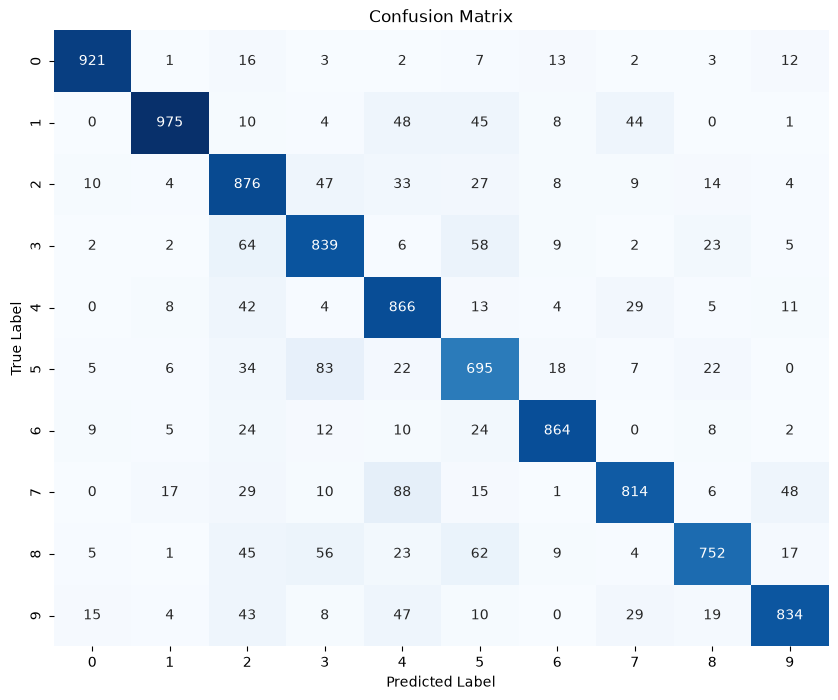

In [8]:
# Visualizing Model Performance

from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

test_predictions = model.predict(test_images)
test_predictions_classes = np.argmax(test_predictions, axis=1)
test_true_classes = np.argmax(test_labels, axis=1)

cm = confusion_matrix(test_true_classes, test_predictions_classes)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

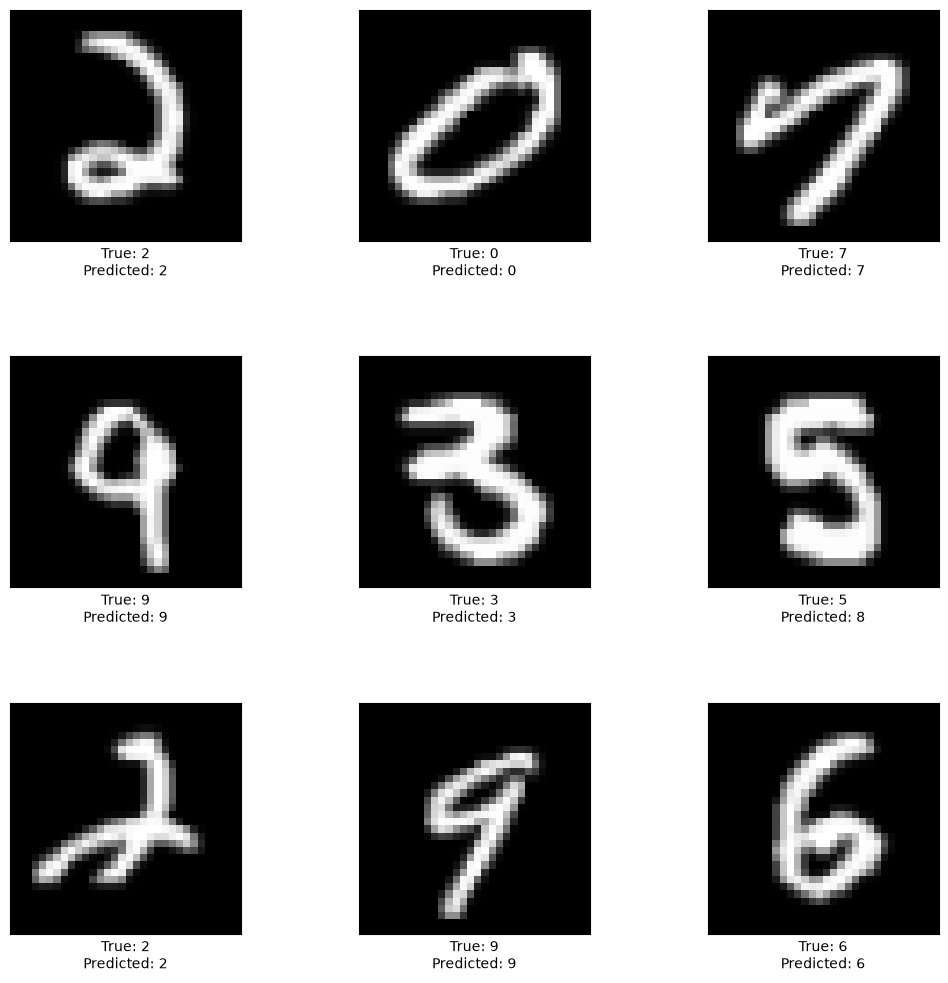

In [9]:
# Sample Image Visualization
def display_sample(sample_images, sample_labels, sample_predictions):
    fig, axes = plt.subplots(3, 3, figsize=(12, 12))
    fig.subplots_adjust(hspace=0.5, wspace=0.5)

    for i, ax in enumerate(axes.flat):
        ax.imshow(sample_images[i].reshape(32, 32), cmap='gray')
        ax.set_xlabel(f"True: {sample_labels[i]}\nPredicted: {sample_predictions[i]}")
        ax.set_xticks([])
        ax.set_yticks([])

    plt.show()

test_images_gray = np.dot(test_images[...,:3], [0.2989, 0.5870, 0.1140])

random_indices = np.random.choice(len(test_images_gray), 9, replace=False)
sample_images = test_images_gray[random_indices]
sample_labels = test_true_classes[random_indices]
sample_predictions = test_predictions_classes[random_indices]
display_sample(sample_images, sample_labels, sample_predictions)